# split cgrp-gamma
KA adding this notebook Jan 2026

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)

In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

In [3]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / 'neuron_filt_adata_subcluster.h5ad' # using 1000 transcripts/cell filtering

## Prepare data

In [29]:
adata = sc.read_h5ad(input_file)
adata.X = adata.layers["log1p"].copy()

In [30]:
adata

AnnData object with n_obs × n_vars = 10276 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

#### Create `reporter_status` column

In [31]:
# add reporter status, either single positive or double postivie
adata.obs['reporter_status'] = 'none'
adata.obs.loc[adata.obs['EGFP_Seq1_hi']==True, 'reporter_status'] = 'EGFP_Seq1_hi'
adata.obs.loc[adata.obs['dTomato_Seq2_hi']==True, 'reporter_status'] = 'dTomato_Seq2_hi'
adata.obs.loc[adata.obs['EGFP_dTomato_dual_hi']==True, 'reporter_status'] = 'EGFP_dTomato_dual_hi'

### CGRP-gamma subclusters

In [32]:
adata

AnnData object with n_obs × n_vars = 10276 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

In [33]:
gamma_adata = adata[adata.obs["cell_type"] == "CGRP-Gamma"].copy() # Seurat-transferred labels

sc.pp.neighbors(gamma_adata, use_rep="X_scVI_neuron_filt")
sc.tl.umap(gamma_adata)
sc.tl.leiden(gamma_adata, resolution=0.1, key_added="gamma_subclusters")

# Identify G1 vs G2 based on ranked Chrna3 mean expression
gamma_adata.obs["Chrna3_temp"] = gamma_adata[:, "Chrna3"].X.toarray().flatten()

cluster_expr = gamma_adata.obs.groupby("gamma_subclusters", observed=False)[
    "Chrna3_temp"
].mean()
g2_cluster = cluster_expr.idxmax()
g1_cluster = cluster_expr.idxmin()

del gamma_adata.obs["Chrna3_temp"] # Clean temporary column

label_map = {g1_cluster: "CGRP-Gamma 1", g2_cluster: "CGRP-Gamma 2"}
gamma_adata.obs["neuron_label"] = gamma_adata.obs["gamma_subclusters"].map(label_map)



In [34]:
gamma_adata

AnnData object with n_obs × n_vars = 1982 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.s

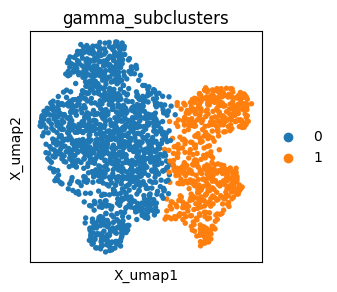

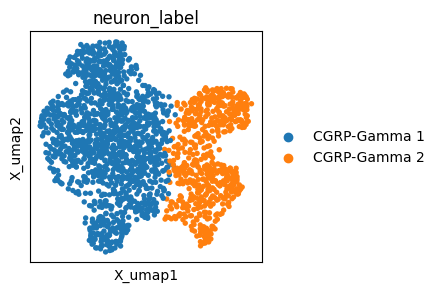

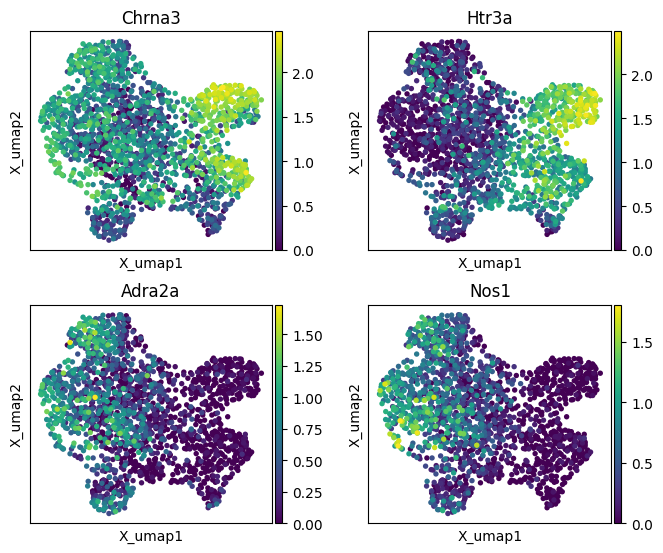

In [49]:
## view subclustered gamma
sc.pl.embedding(gamma_adata, basis = 'X_umap', color = 'gamma_subclusters')
sc.pl.embedding(gamma_adata, basis = 'X_umap', color = 'neuron_label')
sc.pl.embedding(gamma_adata, basis = 'X_umap', ncols = 2, color = ['Chrna3','Htr3a','Adra2a','Nos1'])

In [36]:
gamma_adata.obs['neuron_label'].unique().tolist()

['CGRP-Gamma 1', 'CGRP-Gamma 2']

In [37]:
# Update parent anndata with new labels
adata.obs["neuron_label"] = adata.obs["cell_type"].astype(str)
adata.obs.update(gamma_adata.obs[["neuron_label"]])
adata.obs["neuron_label"] = adata.obs["neuron_label"].astype("category")

In [38]:
adata.obs["neuron_label"].unique().tolist()

['Abeta-RA-LTMR',
 'Proprioceptors',
 'Adelta-LTMR',
 'Nonpeptidergic nociceptors',
 'CGRP-Epsilion',
 'CGRP-Eta',
 'CGRP-Zeta',
 'C-LTMR',
 'CGRP-Alpha',
 'Abeta-Field',
 'CGRP-Theta',
 'CGRP-Gamma 1',
 'TrpM8',
 'Sst',
 'CGRP-Gamma 2',
 'CGRP-Beta']

## Plot final neuron labels on subclustered neuron umap

In [42]:
def assign_cell_type_colors(adata, key="cell_type"):
    """
    Assigns a tab10 color palette to a categorical obs field.
    If there are more than 10 categories, the palette cycles.
    """
    # Ensure categorical
    adata.obs[key] = adata.obs[key].astype("category")
    
    cats = adata.obs[key].cat.categories
    n = len(cats)

    # tab10 gives 10 colors; using modulo lets us cycle if n > 1=20
    base_palette = sns.color_palette("tab20", 20)

    palette = [mcolors.to_hex(base_palette[i % 20]) for i in range(n)]

    # assign colors in category order
    adata.uns[f"{key}_colors"] = palette

In [43]:
assign_cell_type_colors(adata, key="neuron_label")

In [47]:
plt.rcParams['figure.figsize'] = (3, 3)

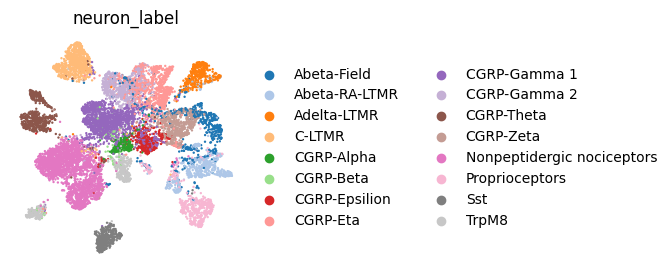

In [48]:
sc.pl.umap(adata, color = 'neuron_label', frameon = False)

# Export

In [45]:
adata_path = os.path.join(output_dir, "neurons-final-labels.h5ad")
adata.write_h5ad(adata_path, compression="gzip")

In [46]:
print(adata_path)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad
